# Photometry Module

**Lecturer:** Sudhanshu Barway<br>
**Jupyter Notebook Author:** Kishalay De & Cameron Hummels

This is a Jupyter notebook lesson taken from the GROWTH Winter School 2018.  For other lessons and their accompanying lectures, please see: http://growth.caltech.edu/growth-astro-school-2018-resources.html

## Objective
Measure photometric fluxes from astronomical ultraviolet, optical, infrared image data.

## Key steps
- Calibrate images to derive relationship between counts and brightness on sky.
- Use aperture photometry tools to calculate brightness of sources.
- Use Point Spread Function photometry tools to calculate brightness of sources.

## Required dependencies

See GROWTH school webpage for detailed instructions on how to install these modules and packages.  Nominally, you should be able to install the python modules with `pip install <module>`.  The external astromatic packages are easiest installed using package managers (e.g., `rpm`, `apt-get`).

### Python modules
* python 3
* astropy
* numpy
* matplotlib
* astroquery

### External packages
* SExtractor https://www.astromatic.net/software
* PSFex https://www.astromatic.net/software

Let's start by importing a few necessary modules first.

In [8]:
import numpy as np
import numpy.ma as ma
import os
import sys
from pathlib import Path
import importlib.util
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats, sigma_clip
import subprocess


def _load_calibrate_photometry():
    """Load ``calibrate_photometry`` without PYTHONPATH (repo root or ``tools/Photometry`` cwd)."""
    cwd = Path.cwd().resolve()
    if (cwd / "calibrate_photometry.py").is_file():
        cp = cwd / "calibrate_photometry.py"
        spec = importlib.util.spec_from_file_location("calibrate_photometry", cp)
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        return mod
    for root in [cwd, *cwd.parents]:
        cp = root / "tools" / "Photometry" / "calibrate_photometry.py"
        if cp.is_file():
            spec = importlib.util.spec_from_file_location("calibrate_photometry", cp)
            mod = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
    raise ImportError(
        "Could not find calibrate_photometry.py (cwd or tools/Photometry)."
    )


cal = _load_calibrate_photometry()
workDir = cal.resolve_photometry_workdir()
print("Photometry workDir:", workDir)

## Test dependencies

In order for this jupyter notebook to function correctly, we must have some external software installed, as described above.  The following step assures that these are installed properly before getting to the rest of the content of this lesson.

In [9]:
dependencies = ['wsl sextractor', 'wsl psfex']

def test_dependency(dep):
    try:
        subprocess.Popen(dep, stderr=subprocess.PIPE).stderr.read()
        print("%s is installed properly. OK" % dep)
        return 1
    except ImportError:
        print("===%s IS NOT YET INSTALLED PROPERLY===" % dep)
        return 0
        
i = 0
for dep in dependencies:
    i += test_dependency(dep)
print("\n%i out of %i dependencies installed properly." % (i, len(dependencies)))
if i != len(dependencies):
    print("Please correctly install these programs before continuing.")
else:
    print("You are ready to continue.")

wsl sextractor is installed properly. OK
wsl psfex is installed properly. OK

2 out of 2 dependencies installed properly.
You are ready to continue.


Let's plot a reduced image from the previous module.

Loading image from: c:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\tools\Photometry\coadded_astrometrically_corrected_rband_r70.fits


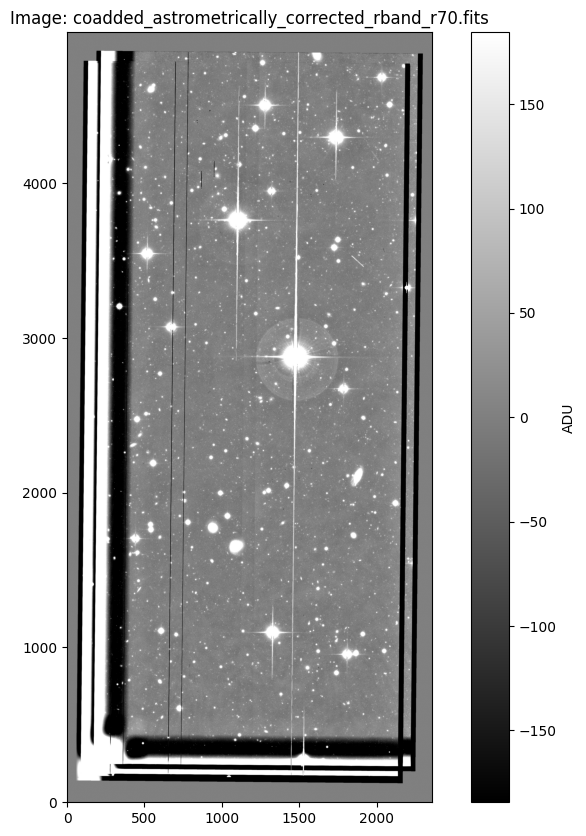

In [10]:
import os
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
import matplotlib.pyplot as plt

# If running in a notebook
%matplotlib inline

# Define the filename
filename = "coadded_astrometrically_corrected_rband_r70.fits"

# Check if the file is in the current directory or the parent directory
if os.path.exists(filename):
    image_path = filename
elif os.path.exists(os.path.join("..", filename)):
    image_path = os.path.join("..", filename)
else:
    raise FileNotFoundError(f"Could not find {filename} in {os.getcwd()} or its parent directory.")

print(f"Loading image from: {os.path.abspath(image_path)}")

# Use a context manager to open the file securely
with fits.open(image_path) as hdul:
    data = hdul[0].data
    header = hdul[0].header

# Compute image statistics
mean, median, sigma = sigma_clipped_stats(data)

# Plot the image with scaled brightness
plt.figure(figsize=(10, 10))
plt.imshow(data, 
           vmin=median - 3 * sigma, 
           vmax=median + 3 * sigma, 
           cmap='gray', 
           origin='lower')

plt.title(f"Image: {os.path.basename(image_path)}")
plt.colorbar(label='ADU')
plt.show()

## Querying an external catalog

The first step is to obtain the known magnitudes of sources in the field in order to subsequently compare them to the measured instrumental magnitudes. We thus have to refer to some external catalog for sources in the field.  For this tutorial, we will refer the Panstarrs 1 (PS1) catalog. We will query PS1 using astropy's query interface _astroquery_ to query the Vizier server and get a list of sources. First, we have to know the coordinates of the center of this field from the image header.

In [11]:
from astropy.wcs import WCS

# Store the image WCS into an object
w = WCS(header)

# Get the RA and Dec of the center of the image
# Note: data.shape is (ny, nx), we swap to get (nx/2, ny/2) for WCS
[raImage, decImage] = w.all_pix2world(data.shape[1]/2, data.shape[0]/2, 1)

# Set the rectangular box dimensions in arcminutes
width_arcmin = 5.47   # RA width
height_arcmin = 13.68  # Dec height

# Magnitude cut-offs of sources to be cross-matched against
maxmag = 18

print(f"Image Center: RA={raImage:.5f}, Dec={decImage:.5f}")
print(f"Search Box: {width_arcmin}' x {height_arcmin}'")

Image Center: RA=64.40027, Dec=7.92688
Search Box: 5.47' x 13.68'


Since PS1 is much deeper than a single image from the GROWTH India telescope, we also put a cut-off on the magnitude range of sources we want to calibrate against. For this specific example, a limiting magnitude of 18 mag in g band should suffice. We also want to reject transients and variable sources in PS1 (need a cut-off on the number of detections in the PS1 survey), and only select sources that have $>3 \sigma$ detections in PS1, so we will incorporate those filters into the PS1 query.

In [12]:
from astroquery.vizier import Vizier
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np

# 1. Define your coordinate limits and center (as before)
ra_min, ra_max = 64.349, 64.441
dec_min, dec_max = 7.82, 8.048
ra_center = (ra_min + ra_max) / 2.0
dec_center = (dec_min + dec_max) / 2.0

# 2. Calculate rectangular dimensions in arcminutes
# height (Dec)
height_arcmin = (dec_max - dec_min) * 60.0
# width (RA) corrected for declination
width_arcmin = (ra_max - ra_min) * 60.0 * np.cos(np.deg2rad(dec_center))

catNum = 'II/349'
maxmag = 18

print(f"\nQuerying PS1 ({catNum}) around RA {ra_center:.4f}, Dec {dec_center:.4f}")
print(f"Rectangle: {width_arcmin:.2f}' x {height_arcmin:.2f}'")

try:
    # Set up filters for clean, high-SNR stellar candidates
    v = Vizier(
        columns=['*'], 
        column_filters={
            "rmag": f"< 20",   # 1. Brightness limit
            "Nd": "> 6",                 # 2. Minimum detections
            "e_rmag": f"< {1.086/3:.3f}" # 3. Signal-to-Noise Ratio (SNR) limit
        },
        row_limit=-1
    )
    
    # Query using WCS-aligned width and height
    Q = v.query_region(
        SkyCoord(ra=ra_center, dec=dec_center, unit=(u.deg, u.deg)),
        width=width_arcmin * u.arcmin,
        height=height_arcmin * u.arcmin,
        catalog=catNum, 
        cache=False
    )
    
    if Q and len(Q) > 0:
        print(f"Found {len(Q[0])} sources.")
        display(Q[0][:5])
    else:
        print("No sources found matching these filters in this area.")

except Exception as e:
    print(f"Error querying PS1: {e}")



Querying PS1 (II/349) around RA 64.3950, Dec 7.9340
Rectangle: 5.47' x 13.68'
Found 66 sources.


RAJ2000,DEJ2000,objID,f_objID,Qual,e_RAJ2000,e_DEJ2000,Epoch,Ns,Nd,gmag,e_gmag,gKmag,e_gKmag,gFlags,rmag,e_rmag,rKmag,e_rKmag,rFlags,imag,e_imag,iKmag,e_iKmag,iFlags,zmag,e_zmag,zKmag,e_zKmag,zFlags,ymag,e_ymag,yKmag,e_yKmag,yFlags
deg,deg,,,,arcsec,arcsec,d,,,mag,mag,mag,mag,,mag,mag,mag,mag,,mag,mag,mag,mag,,mag,mag,mag,mag,,mag,mag,mag,mag,
float64,float64,int64,int64,int16,float64,float64,float64,int16,int16,float64,float32,float64,float32,int32,float64,float32,float64,float32,int32,float64,float32,float64,float32,int32,float64,float32,float64,float32,int32,float64,float32,float64,float32,int32
64.403575980,7.820127830,117380644035124643,436527104,52,0.0059,0.0048,56263.163900460,5,84,20.0959,0.0159,20.1554,0.0259,115000,19.5290,0.0075,19.6304,0.0210,115000,19.2760,0.0104,19.3806,0.0173,115000,19.1719,0.0205,19.2556,0.0256,115000,19.0653,0.0353,19.0600,0.0660,115000
64.425008960,7.853863310,117420644250315100,503635968,60,0.0091,0.0023,56296.964108800,5,63,19.9212,0.0114,20.0354,0.0197,115000,18.9445,0.0112,19.0884,0.0171,115000,18.4980,0.0055,18.5923,0.0120,115000,18.2726,0.0037,18.3550,0.0150,115000,18.1393,0.0134,18.2895,0.0419,115000
64.423909330,7.829095720,117390644239015395,503635968,60,0.0019,0.0045,56312.415138890,5,70,17.5351,0.0067,17.5892,0.0042,115000,16.8963,0.0029,16.9716,0.0036,115000,16.5973,0.0019,16.6546,0.0032,115000,16.4455,0.0040,16.5130,0.0069,115000,16.3344,0.0040,16.3992,0.0135,115000
64.430115920,7.855132290,117420644301096635,503635968,60,0.0025,0.0024,56216.520370370,5,77,17.2469,0.0033,17.3150,0.0027,115000,16.6613,0.0039,16.7370,0.0041,115000,16.4043,0.0016,16.4715,0.0047,115000,16.3025,0.0035,16.3554,0.0047,115000,16.1880,0.0044,16.2562,0.0163,115000
64.370753170,7.840982670,117410643707100169,436281344,52,0.0065,0.0065,56315.108425930,5,13,18.5822,0.0072,18.6851,0.0096,115000,17.8653,0.0042,17.9338,0.0020,115000,17.4582,0.0026,17.5299,0.0066,115000,--,--,--,--,114720,18.8815,0.1659,--,--,118832


Just in case the Vizier query did not go through (this can happen, depending on the load on the Vizier servers), read in the source table in the file ps1_v641cyg.tab. No need to do this step if your query did go through.

The query should have retrieved about 10,000 known sources in this field. We will now filter stars that are away from the edges of the image (same as in the case of the SExtractor detected sources). Note that you can also put additional filters in the catalog sources by just adding more conditions to the the commands below.

Using the same method as we used to figure out the center of the image, use the catalog coordinates from the astropy table to get image coordinates of the sources. Then create a table called good_cat_stars to only store stars that within the pixel range (500, 3500) in both x and y directions in the image.

In [13]:
# Convert world coordinates to image coordinates just for plotting/matching
ps1_imCoords = w.all_world2pix(Q[0]['RAJ2000'], Q[0]['DEJ2000'], 1)

# Since we already queried for the exact rectangle, we can use all returned stars
good_cat_stars = Q[0] 

print(f"Using all {len(good_cat_stars)} stars from the rectangular query.")


Using all 66 stars from the rectangular query.


Let's get the image coordinates of the filtered good catalog stars and plot them on the image.

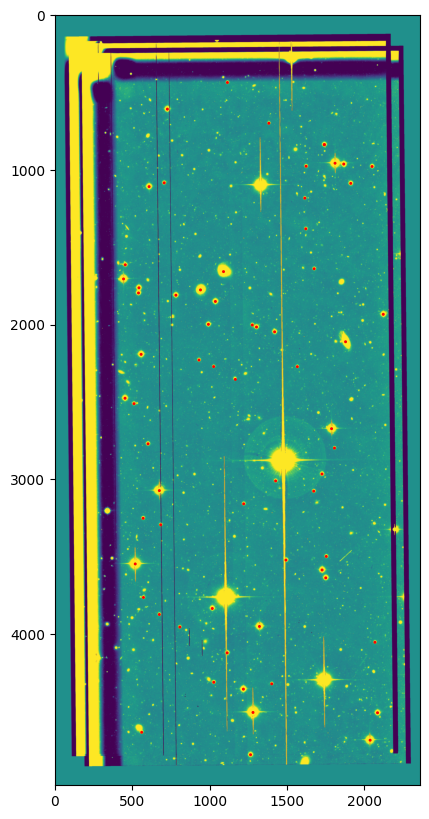

In [14]:
ps1_imCoords = w.all_world2pix(good_cat_stars['RAJ2000'],good_cat_stars['DEJ2000'], 1)

fig = plt.figure(figsize=(10,10))
ax = fig.gca()
plt.imshow(data, vmin=median-3*sigma, vmax=median+3*sigma)
circles = [plt.Circle((ps1_imCoords[0][i], ps1_imCoords[1][i]), radius = 5, edgecolor='r', facecolor='None') for i in range(len(ps1_imCoords[0]))]
for c in circles:
    ax.add_artist(c)
    
plt.show()

## Aperture photometry

To start with aperture photometry, we have to identify point sources in this image and compare their brightness to a known catalog. We will use a popular code known as 'Source Extractor' (a.k.a. SExtractor) to detect point sources in the image.

### Source detection

SExtractor is a very powerful code, and can do a large range of complex source detection tasks, but needs to be appropriately configured via its configuration and parameter file to specify the kind of sources we want to detect and the parameters we want to measure.

In this case, you have a configuration file available in the directory designed to detect sources above a 10$\sigma$ threshold from the background and measure it's flux. We'll go over the details, but let's see how SExtractor runs first.

In [15]:
import subprocess

# Hardcoded absolute path as requested
workDir = cal.resolve_photometry_workdir()
imageName = "coadded_astrometrically_corrected_rband_r70.fits"
configFile = "photomCat.sex"
catalogName = imageName + ".cat"
paramName = "photomCat.param"

# Use wsl --cd to tell WSL precisely where to run
try:
    command = f'wsl --cd "{workDir}" source-extractor -c {configFile} {imageName} -CATALOG_NAME {catalogName} -PARAMETERS_NAME {paramName}'
    
    print(f"Executing: {command}")
    
    # Run the command
    result = subprocess.run(command, shell=True, check=True, capture_output=True, text=True)
    
    print("\nSUCCESS: SExtractor finished.")
    print(result.stdout)

except subprocess.CalledProcessError as err:
    print(f"\nFAILED with exit code {err.returncode}")
    print(f"Error output:\n{err.stderr}")


Executing: wsl --cd "C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\Photometry" source-extractor -c photomCat.sex coadded_astrometrically_corrected_rband_r70.fits -CATALOG_NAME coadded_astrometrically_corrected_rband_r70.fits.cat -PARAMETERS_NAME photomCat.param

FAILED with exit code 4294967295
Error output:



Here, we are running SExtractor with a configuration file specified with the '-c' flag and asking it to output the list of sources it deteced to a file called imageName+'.cat' in a format known as the FITS LDAC. The ouput parameters to be produced by SExtractor are in the file 'photomCat.param' and specified by the flag 'PARAMETERS_NAME'. We will now read in the source catalog produced by SExtractor into an astropy table. Before that, here is a function to read FITS LDAC tables with astropy.

In [16]:
import os
from astropy.table import Table

# Hardcoded path to your working directory
workDir = cal.resolve_photometry_workdir()
imageName = "coadded_astrometrically_corrected_rband_r70.fits"
catalogName = os.path.join(workDir, imageName + '.cat')

def get_table_from_ldac(filename, frame=1):
    """
    Load an astropy table from a fits_ldac by frame.
    """
    if frame > 0:
        # LDAC files have 2 HDUs per table (one for metadata/header, one for data)
        # Table data is usually in HDU 2, 4, 6...
        frame = frame * 2
    
    tbl = Table.read(filename, hdu=frame)
    return tbl 

# Now reading the absolute path
try:
    sourceTable = get_table_from_ldac(catalogName)
    print(f"Successfully loaded {len(sourceTable)} sources from {os.path.basename(catalogName)}")
    print("\nColumns available:")
    print(sourceTable.colnames)
    display(sourceTable[:5]) # Display the first 5 rows nicely
    
except FileNotFoundError:
    print(f"ERROR: Could not find the file at {catalogName}")
except Exception as e:
    print(f"An error occurred: {e}")


ERROR: Could not find the file at C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\Photometry\coadded_astrometrically_corrected_rband_r70.fits.cat


Note the columns in the output table -- important ones are 'XWIN_IMAGE' and 'YWIN_IMAGE' that are the centroids of the detected stars in image coordinates while 'ALPHAWIN_J2000' and 'DELTAWIN_J2000' are the same in world coordinates. We also have the background subtracted flux of the sources measured in fixed apertures ('FLUX_APER') and the magnitudes in fixed apertures ('MAG_APER').

In order to derive a good photometric solution, we want to find 'clean' sources that are not blended with other objects and are away from the edges of the image, and get their instrumental magnitudes. The SExtractor output has a 'FLAGS' column that indicates unblended sources away from bad pixels with FLAGS = 0 (read the SExtractor manual to find out what other values of the flags mean). In order to get point-like sources, we also want the FWHM of the source to be smaller than about 2 arc seconds that are away from the edges of the image. So let's select the sources that satisfy this condition.

In [17]:
import numpy as np

# 1. Define your exact limits
ra_min, ra_max = 64.349, 64.441
dec_min, dec_max = 7.82, 8.048

# 2. Define a buffer (optional - avoids edge artifacts)
# 30 pixels is roughly 0.002 degrees (depending on your pixel scale)
buffer_deg = 0.002 

# 3. Apply filters
# We use ALPHAWIN_J2000 and DELTAWIN_J2000 for precision
cleanSources = sourceTable[
    (sourceTable['FLAGS'] == 0) &                       # Clean detections
    (sourceTable['FWHM_WORLD'] < (2.0/3600.0)) &         # Stars: FWHM < 2 arcsec (conv to deg)
    (sourceTable['ALPHAWIN_J2000'] > ra_min + buffer_deg) &
    (sourceTable['ALPHAWIN_J2000'] < ra_max - buffer_deg) &
    (sourceTable['DELTAWIN_J2000'] > dec_min + buffer_deg) &
    (sourceTable['DELTAWIN_J2000'] < dec_max - buffer_deg)
]

print(f"Total detections: {len(sourceTable)}")
print(f"Clean stellar sources in cutout: {len(cleanSources)}")

# Display the detected coordinates to confirm they span the whole box
print(f"RA Range: {cleanSources['ALPHAWIN_J2000'].min():.4f} to {cleanSources['ALPHAWIN_J2000'].max():.4f}")
print(f"Dec Range: {cleanSources['DELTAWIN_J2000'].min():.4f} to {cleanSources['DELTAWIN_J2000'].max():.4f}")


NameError: name 'sourceTable' is not defined

Now overlay these detected sources on the reduced image to see how sextractor performed

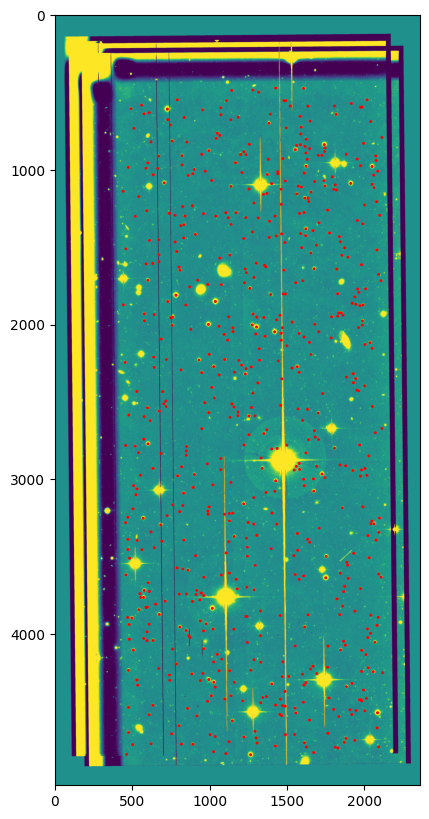

In [ ]:
fig = plt.figure(figsize=(10,10))
ax = fig.gca()
plt.imshow(data, vmin=median-3*sigma, vmax=median+3*sigma)
#plotting circles on top of all detected sources
circles = [plt.Circle((source['XWIN_IMAGE'], source['YWIN_IMAGE']), radius = 5, edgecolor='r', facecolor='None') for source in cleanSources]
for c in circles:
    ax.add_artist(c)


plt.show()

### Catalog cross-matching

So far, we have the catalog of sources detected in the image, and an external catalog of sources we want to compare against. The next step is to cross-match the two catalogs and find associations between sources detected in the image and sources on the sky.

In [ ]:
import astropy.units as u

# 1. Define your SkyCoords (using your clean variables)
sourceCatCoords = SkyCoord(
    ra=cleanSources['ALPHAWIN_J2000'], 
    dec=cleanSources['DELTAWIN_J2000'], 
    frame='icrs', unit='degree'
)
ps1CatCoords = SkyCoord(
    ra=good_cat_stars['RAJ2000'], 
    dec=good_cat_stars['DEJ2000'], 
    frame='icrs', unit='degree'
)

# 2. Perform one-to-one matching 
# This finds the closest PS1 star for EVERY image source
idx_ps1, d2d, d3d = sourceCatCoords.match_to_catalog_sky(ps1CatCoords)

# 3. Set the distance threshold (0.6 arcsec)
photoDistThresh = 0.6 * u.arcsec
sep_constraint = d2d < photoDistThresh

# 4. Filter to keep only the good matches
# 'matched_image_sources' are the ones SExtractor found
# 'matched_ps1_stars' are the corresponding values from the PS1 catalog
matched_image_sources = cleanSources[sep_constraint]
matched_ps1_stars = good_cat_stars[idx_ps1[sep_constraint]]

print(f"Found {len(matched_image_sources)} solid one-to-one cross-matches.")


Found 38 solid one-to-one cross-matches.


### Zero-point derivation

Now that we have cross-matched sources between the image and PS1, we can start deriving zero-points. Recall that the instrumental magnitude of a source is related to its physical magnitude via the zero-point relation

<h2> <center>

$m_{app}$ = ZP + $m_{ins}$ <br><br>

$m_{ins} = -2.5 \, \textrm{log} \, (\textrm{Total flux})$

</center></h2>

It should be easy to see that the instrumental magniutde of a source depends on the way you measure the flux, and this is exactly where the different ways of photometry come into play.

As we've already discussed, aperture photometry involves measuring the flux of a source in a fixed aperture of some radius. The amount of flux you measure is also dependent on the size of the aperture you choose. The larger the aperture, the more flux you capture from the wings of the PSF. At the same time, a larger aperture might also have contamination from neighboring sources, so you have to be careful.

In order to be consistent with flux measurements of your catalog calibrators and your target, you have to measure fluxes in the same apertures so that you are 'missing' the same fraction of flux between your calibrators and target source. As the zero-point depends on the difference between the catalog and instrumental magnitudes, the zero-point you derive will also be a function of the size of the aperture you choose -- so an aperture specific zero-point will allow us to account for these issues. Let's see an example of this.

The SExtractor catalogs we got from the image actually also contains aperture photometry for the detected sources in the 'MAG_APER' keyword, so most of our work is actually already done. In this case, the SExtractor parameter file already specified the diameter of the apertures we wanted to measure: 4.0 pixels to 13.0 pixels in steps of 1.0 pixel. 

__Exercise__: Go ahead and look at the SExtractor configuration file and find where these apertures are specified.

To see how the measured instrumental magnitude changes between apertures of different sizes, we can plot the differences between the magnitude measured in the largest aperture (13.0 pixels) and every other aperture and plot the differences. 

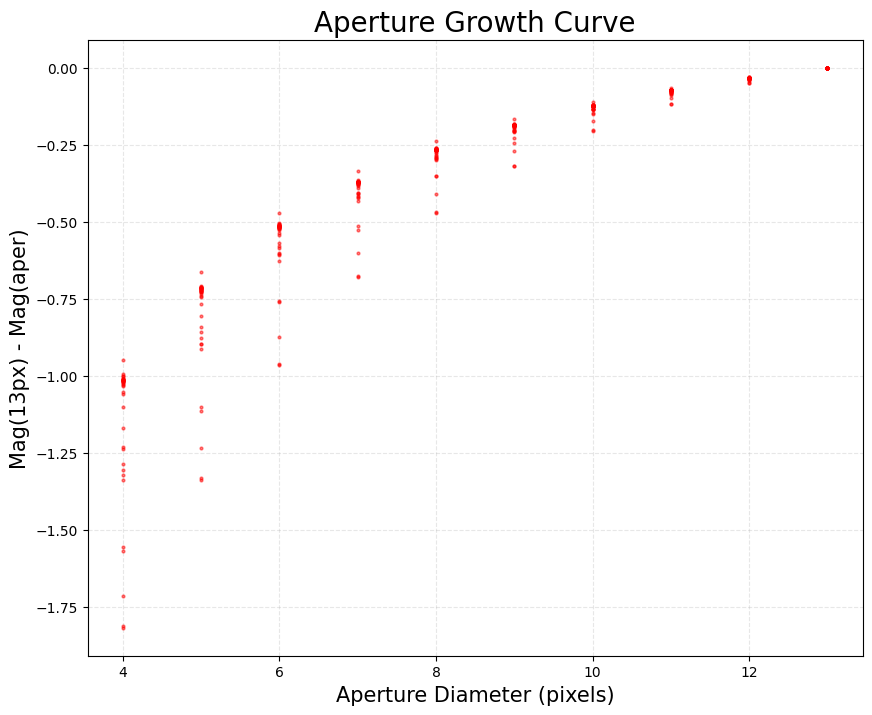

Number of stars found: 38


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip

# 1. Defined apertures from your .sex file (4 to 13 pixels)
aperture_diameter = np.arange(4, 14)
# Index 9 is the largest aperture (13.0 pixels)
largest_aper_idx = 9 

# 2. Compute magnitude differences
# We are comparing each aperture TO the largest one (13px)
# This results in a 2D array: [Aperture_Index, Star_Index]
magDiff = []

for j in range(len(aperture_diameter)):
    # Calculate difference for all matched stars at this aperture
    diffs = matched_image_sources['MAG_APER'][:, largest_aper_idx] - matched_image_sources['MAG_APER'][:, j]
    # We use sigma_clip to remove outliers (e.g., stars near bright neighbors)
    magDiff.append(sigma_clip(diffs))

magDiff = np.array(magDiff)

# Create the figure
plt.figure(figsize=(10, 8))

# Plot the individual data for every star
# Only plotting the red dots as requested
plt.plot(aperture_diameter, magDiff, 'r.', markersize=4, alpha=0.5)

plt.title('Aperture Growth Curve', fontsize=20)
plt.xlabel('Aperture Diameter (pixels)', fontsize=15)
plt.ylabel('Mag(13px) - Mag(aper)', fontsize=15)
plt.grid(alpha=0.3, linestyle='--')
plt.show()

print(f"Number of stars found: {magDiff.shape[1]}")




As apparent, the magnitudes become systematically fainter for smaller apertures. Recall that the larger the aperture, the more flux and the lower magnitude. This curve is often called as the __Curve of Growth__.

Now, let's overplot the instrumental (for any given aperture) and PS1 magnitudes for the good cross-matched sources.

Matches found: 39


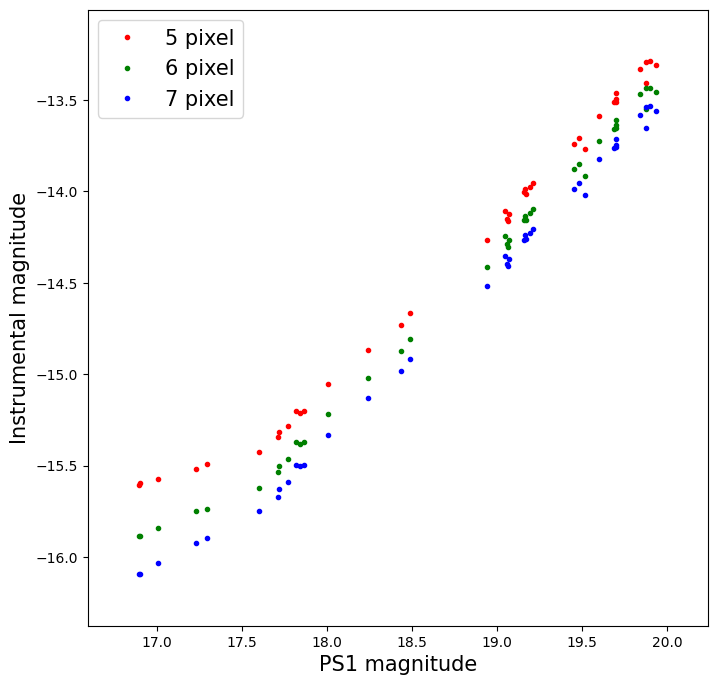

In [ ]:
import astropy.units as u

# 1. First, make sure the coordinates are fresh
source_coords = SkyCoord(ra=cleanSources['ALPHAWIN_J2000'], dec=cleanSources['DELTAWIN_J2000'], unit=u.deg)
catalog_coords = SkyCoord(ra=good_cat_stars['RAJ2000'], dec=good_cat_stars['DEJ2000'], unit=u.deg)

# 2. Run the match and assign variables correctly
# idx1 (first) maps to source_coords -> idx_image
# idx2 (second) maps to catalog_coords -> idx_ps1
idx_image, idx_ps1, d2d, d3d = catalog_coords.search_around_sky(source_coords, photoDistThresh)

print(f"Matches found: {len(idx_image)}")

# 3. Your Simple Plotting Code (Unaltered logic)
plt.figure(figsize=(8,8))
plt.plot(good_cat_stars['rmag'][idx_ps1], cleanSources['MAG_APER'][idx_image, 2], 'r.', label='5 pixel')
plt.plot(good_cat_stars['rmag'][idx_ps1], cleanSources['MAG_APER'][idx_image, 3], 'g.', label='6 pixel')
plt.plot(good_cat_stars['rmag'][idx_ps1], cleanSources['MAG_APER'][idx_image, 4], 'b.', label='7 pixel')

# Use auto-scaling so nothing is cut off
plt.autoscale(enable=True, tight=False)
plt.margins(0.1)

plt.xlabel('PS1 magnitude', fontsize=15)
plt.ylabel('Instrumental magnitude', fontsize=15)
plt.legend(fontsize=15)
plt.show()


That is a good correlation between the PS1 and instrumental magnitudes, also showing the small systematic offsets between the magnitudes of different aperture sizes. 

We are ready to derive a zero-point for each aperture. From the earlier equation, the zero-point is just the difference between the catalog and instrumental magnitudes, so we want to measure the average offset between these magnitudes, including rejection of bad outliers that might affect the photometry. The results will be stored in an array of dictionaries containing the mean, median and standard deviation of the zero-point.

In [ ]:
import numpy as np
from numpy import ma
from astropy.stats import sigma_clipped_stats

# 1. Initialize the ZeroPoint container
zeroPoints = []

# 2. Loop through all 10 apertures (4 to 13 pixels)
for i in range(len(aperture_diameter)):
    
    # Calculate the OFFSET: Catalog Magnitude - Instrumental Magnitude
    # This is the "Zero Point" that shifts your data to the PS1 scale
    offsets = ma.array(good_cat_stars['rmag'][idx_ps1] - cleanSources['MAG_APER'][:,i][idx_image])
    
    # Use sigma clipping to ignore any bad matches or noisy stars
    # This returns: mean, median, and stddev of the Zero Point
    zero_mean, zero_med, zero_std = sigma_clipped_stats(offsets, sigma=3, maxiters=10)
    
    # Store the results
    zeroDict = {
        'diameter': aperture_diameter[i], 
        'zp_mean': zero_mean, 
        'zp_median': zero_med, 
        'zp_std': zero_std
    }
    zeroPoints.append(zeroDict)
    
    # Print the result for each aperture
    print(f"Aperture {aperture_diameter[i]:.1f}px: ZP = {zero_med:.4f} +/- {zero_std:.4f}")

# 3. Final Calibration Choice
# We usually use the largest aperture (13px) for the final Zero Point
final_zp = zeroPoints[-1]['zp_median']
print(f"\nRecommended Final Zero Point (13px aperture): {final_zp:.4f}")


Aperture 4.0px: ZP = 32.6746 +/- 0.1400
Aperture 5.0px: ZP = 32.9642 +/- 0.0982
Aperture 6.0px: ZP = 33.1706 +/- 0.0700
Aperture 7.0px: ZP = 33.3140 +/- 0.0575
Aperture 8.0px: ZP = 33.4226 +/- 0.0513
Aperture 9.0px: ZP = 33.4995 +/- 0.0484
Aperture 10.0px: ZP = 33.5647 +/- 0.0465
Aperture 11.0px: ZP = 33.6144 +/- 0.0517
Aperture 12.0px: ZP = 33.6521 +/- 0.0852
Aperture 13.0px: ZP = 33.6848 +/- 0.0816

Recommended Final Zero Point (13px aperture): 33.6848


As apparent, the zero-point changes with the size of the aperture. So, when you want to derive photometry, you should measure fluxes in an aperture and apply the zero-point correction for the same aperture to get accurate photometry. This correction for the aperture size is known as an __Aperture correction__. 

We will apply the respective zero-point corrections and compute uncertainties by adding the measured magnitude uncertainties and zero-point uncertainties in quadrature.

In [ ]:
# 1. Find your target in the catalog (e.g., closest to your center)
from astropy.coordinates import SkyCoord
import astropy.units as u

target_coord = SkyCoord(ra=64.4, dec=7.93, unit=u.deg) # Example center
catalog_coords = SkyCoord(ra=sourceTable['ALPHAWIN_J2000'], dec=sourceTable['DELTAWIN_J2000'], unit=u.deg)
idx, d2d, _ = target_coord.match_to_catalog_sky(catalog_coords)

# 2. Extract its 10 aperture magnitudes
target_mags = sourceTable[idx]['MAG_APER']
target_errs = sourceTable[idx]['MAGERR_APER']

# 3. Apply your correction loop
for i in range(len(target_mags)):
    # Since SExtractor was run with ZP=0, we don't need the "-25" 
    # unless your specific formula requires an IRAF-base offset.
    magCorrected = target_mags[i] + zeroPoints[i]['zp_median']
    magCorrectedErr = np.sqrt(zeroPoints[i]['zp_std']**2 + target_errs[i]**2)
    
    print(f'Aperture {zeroPoints[i]["diameter"]:.1f}px: Corrected Mag = {magCorrected:.2f} +/- {magCorrectedErr:.2f}')


Aperture 4.0px: Corrected Mag = 23.65 +/- 0.14
Aperture 5.0px: Corrected Mag = 23.60 +/- 0.10
Aperture 6.0px: Corrected Mag = 23.56 +/- 0.07
Aperture 7.0px: Corrected Mag = 23.52 +/- 0.06
Aperture 8.0px: Corrected Mag = 23.50 +/- 0.05
Aperture 9.0px: Corrected Mag = 23.47 +/- 0.05
Aperture 10.0px: Corrected Mag = 23.46 +/- 0.05
Aperture 11.0px: Corrected Mag = 23.44 +/- 0.05
Aperture 12.0px: Corrected Mag = 23.43 +/- 0.09
Aperture 13.0px: Corrected Mag = 23.43 +/- 0.08


Note that the aperture photometry magnitudes are completely consistent with each other within the errors of the measurements (the physical magnitude of a source should not depend on the aperture you used to measure the flux), suggesting that the aperture corrections worked fine. Also note that the errors become progressively larger for large apertures since we are accumulating more noise from the background. 

__Question__ : Can you think of another way we could have obtained by the aperture photomtery magnitude for this source? Think of what was contained in the SExtractor catalogs -- how would you extract the magnitudes for the source from the SExtractor catalog?

## PSF Photometry

Aperture photometry is fairly straightforward and works well for sources that are relatively isolated (there are no other sources in the aperture or the background). However, this may not be the case for sources in crowded fields (e.g. the galactic plane), where finding a source-free aperture can be difficult. This is where PSF photometry comes in.

### Creating a PSF model

The idea behind PSF photometry is to create a model for the Point Spread Function of stars in the field by fitting a large number of stars. The models are then iteratively subtracted from the data and refined to minimize the residuals. There are a number of PSF photometry packages in use today, with varying degrees of manual innvolvement and automation. For this module, we will use a package known as PSFEx, also from the Astromatic set of codes. 

PSFEx takes a SExtractor catalog as input. The catalog should be in the FITS LDAC format and contain cut-outs of the detected stars in the field, on which it performs the model fitting. For this module, we actually already produced the star cut-outs when we ran SExtractor the first time -- the 'PARAMETERS_NAME' file had an entry called VIGNET, specifying the size of the cut-out around each star. We will now run PSFEx on this catalog and try to produce a PSF model for the image. We again have an input configuration file called 'psfex_conf.psfex' that specified the run-time parameters for PSFEx.

In [ ]:
import subprocess
import os

psfConfigFile = 'psfex_conf.psfex'
catalogName = imageName + '.cat'
# Hardcoding the working directory as we did for SExtractor
workDir = cal.resolve_photometry_workdir()

try:
    # Run PSFEx directly inside the Photometry folder
    command = f'wsl --cd "{workDir}" psfex -c {psfConfigFile} {catalogName}'
    print(f'Executing command: {command}')
    
    # We capture the output so we can debug any "missing library" errors
    result = subprocess.run(command, shell=True, check=True, capture_output=True, text=True)
    print("PSFEx completed successfully!")
    
except subprocess.CalledProcessError as err:
    print(f'PSFEx failed with exit code {err.returncode}')
    print(f'Error output:\n{err.stderr}')
    print(f'Standard output:\n{err.stdout}')


Executing command: wsl --cd "C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\Photometry" psfex -c psfex_conf.psfex coadded_astrometrically_corrected_rband_r70.fits.cat
PSFEx completed successfully!


Now plot the PSF model produced by PSFEx. The best-fit Moffat model is stored as a FITS file in the output image 'moffat_' + imageName + '.fits'.

Loading PSF model from: C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\Photometry\moffat_coadded_astrometrically_corrected_rband_r70.fits.fits


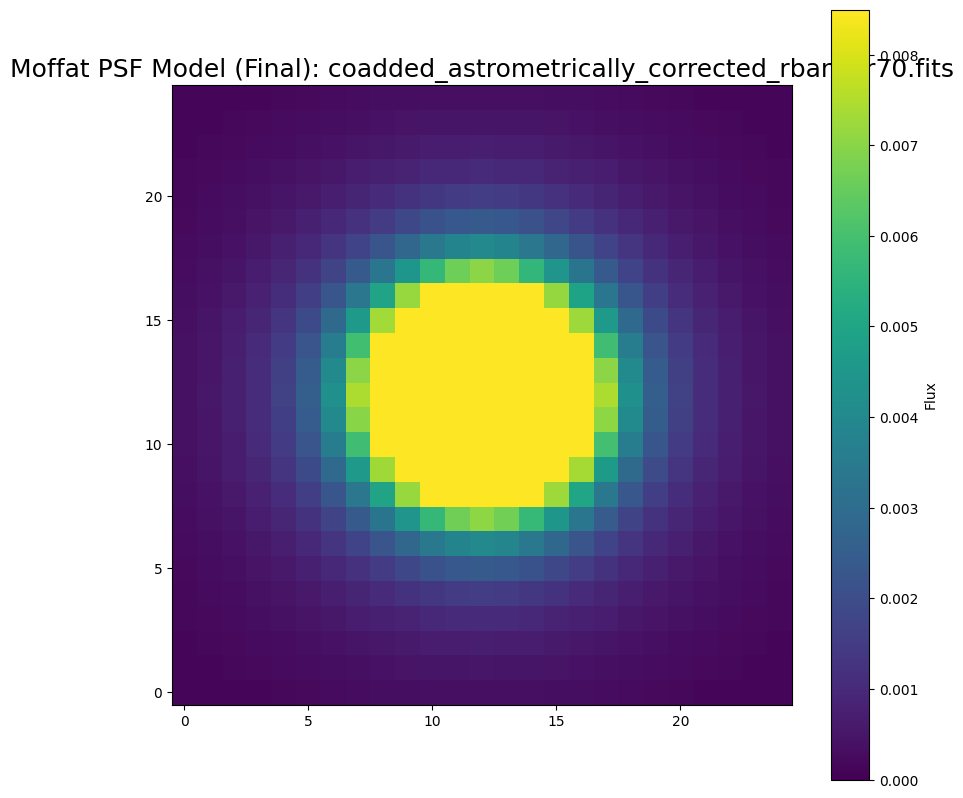

In [ ]:
import os
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

# 1. Update the path
psfFileName = 'proto_' + imageName + '.fits'
psfPath = os.path.join(workDir, psfFileName)

print(f"Loading PSF model from: {psfPath}")

# 2. Use a context manager to ensure the file handle is closed on the next line
with fits.open(psfPath) as hdul:
    # Use .copy() to bring the pixel data fully into memory
    psfModelData = hdul[0].data.copy()

# 3. Standard plotting and stats
mean, median, std = sigma_clipped_stats(psfModelData)

plt.figure(figsize=(10, 10))
plt.imshow(psfModelData, origin='lower', cmap='viridis', vmin=0, vmax=median+10*std)
plt.colorbar(label='Flux')
plt.title(f'Moffat PSF Model (Final): {imageName}', fontsize=18)
plt.show()


It is also instructive to have a look at the radial profile of the best-fit PSF model. Let's make a radial profile and plot it.

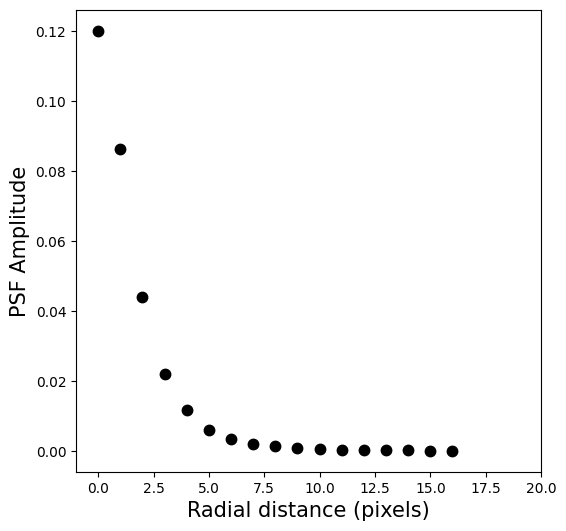

In [ ]:
psfImageCenter = [(psfModelData.shape[0]-1)/2, (psfModelData.shape[1]-1)/2]
y, x = np.indices(psfModelData.shape)
r = np.sqrt((x-psfImageCenter[0])**2 + (y-psfImageCenter[1])**2)
r = r.astype(int)

tbin = np.bincount(r.ravel(), psfModelData.ravel())
nr = np.bincount(r.ravel())
radialprofile = tbin/nr

plt.figure(figsize=(6,6))
plt.plot(range(len(radialprofile)), radialprofile, 'k.', markersize=15)
plt.xlabel('Radial distance (pixels)', fontsize=15)
plt.ylabel('PSF Amplitude', fontsize=15)
plt.xlim(-1,20)
plt.show()

__Question__: Figure out why the above code is able to produce the radial profile of the PSF.

### Computing PSF-fit photometry for point sources

We can now feed this PSF model back to SExtractor to make it perform PSF model fitting on each of the detected sources and produce PSF-fit fluxes for each source. The full PSF model is stored in a file called imageName + '.psf'. This can take a bit of time depending on how fast your machine is.

In [ ]:
import subprocess
import os

# Using the literal filenames with the double extensions as they exist now
fitsFile = 'coadded_astrometrically_corrected_rband_r70.fits'
psfName = 'coadded_astrometrically_corrected_rband_r70.fits.psf'
psfcatalogName = 'coadded_astrometrically_corrected_rband_r70.fits.psf.cat'
psfparamName = 'photomPSF.param'

workDir = cal.resolve_photometry_workdir()

try:
    # Run SExtractor using the .psf model file
    command = (
        f'wsl --cd "{workDir}" source-extractor -c PSFPhotom.sex {fitsFile} '
        f'-CATALOG_NAME {psfcatalogName} '
        f'-PSF_NAME {psfName} '
        f'-PARAMETERS_NAME {psfparamName} '
        f'-MAG_ZEROPOINT 0' 
    )
    
    print(f"Executing PSF Photometry: {command}")
    
    # Run it
    result = subprocess.run(command, shell=True, check=True, capture_output=True, text=True)
    print("PSF-convolved SExtractor run completed successfully!")
    
except subprocess.CalledProcessError as err:
    print(f'PSF SExtractor failed with exit code {err.returncode}')
    print(f'Error output:\n{err.stderr}')


Executing PSF Photometry: wsl --cd "C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\Photometry" source-extractor -c PSFPhotom.sex coadded_astrometrically_corrected_rband_r70.fits -CATALOG_NAME coadded_astrometrically_corrected_rband_r70.fits.psf.cat -PSF_NAME coadded_astrometrically_corrected_rband_r70.fits.psf -PARAMETERS_NAME photomPSF.param -MAG_ZEROPOINT 0
PSF-convolved SExtractor run completed successfully!


Let's read in the new PSF-fit SExtractor catalog as before and check it's contents. You should find additional new columns like 'MAG_POINTSOURCE' and 'MAGERR_POINTSOURCE' -- these are the new PSF model fit magnitudes measured with SExtractor.

In [ ]:
def get_table_from_ldac(filename, frame=1):
    """
    Load an astropy table from a fits_ldac by frame (Since the ldac format has column 
    info for odd tables, giving it twce as many tables as a regular fits BinTableHDU,
    match the frame of a table to its corresponding frame in the ldac file).
    
    Parameters
    ----------
    filename: str
        Name of the file to open
    frame: int
        Number of the frame in a regular fits file
    """
    from astropy.table import Table
    if frame>0:
        frame = frame*2
    tbl = Table.read(filename, hdu=frame)
    return tbl

In [ ]:
import os
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import pandas as pd

# 1. Redefine the function with the explicit format fix
def get_table_from_ldac(filename, frame=1):
    """
    Load an astropy table from a fits_ldac by frame.
    Explicitly set format='fits' to avoid IORegistryError.
    """
    if frame > 0:
        # LDAC files have 2 HDUs per table (metadata + data)
        # Table data is typically in HDU 2, 4, 6...
        frame = frame * 2
    
    # The fix: explicitly define the format as 'fits'
    tbl = Table.read(filename, hdu=frame, format='fits')
    return tbl

# 2. Setup paths (Matching your previous run)
workDir = cal.resolve_photometry_workdir()
imageName = 'coadded_astrometrically_corrected_rband_r70.fits'
psfcatalogName = imageName + '.psf.cat'
psfCatalogPath = os.path.join(workDir, psfcatalogName)

print(f"Loading PSF Catalog from: {psfCatalogPath}")

# 3. Load the catalog
psfsourceTable = get_table_from_ldac(psfCatalogPath)

print("--- PSF Catalog loaded successfully ---")
print(f"Number of objects detected: {len(psfsourceTable)}")
psfsourceTable.info()


Loading PSF Catalog from: C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\Photometry\coadded_astrometrically_corrected_rband_r70.fits.psf.cat
--- PSF Catalog loaded successfully ---
Number of objects detected: 787
<Table length=787>
          name            dtype   shape   unit  format 
------------------------ ------- -------- ---- --------
                  VIGNET float32 (27, 27)   ct {:12.7g}
                 X_IMAGE float32           pix {:11.4f}
                 Y_IMAGE float32           pix {:11.4f}
              XWIN_IMAGE float64           pix {:11.4f}
              YWIN_IMAGE float64           pix {:11.4f}
           ERRAWIN_IMAGE float32           pix  {:9.5f}
           ERRBWIN_IMAGE float32           pix  {:9.5f}
          ALPHAWIN_J2000 float64           deg {:11.7f}
          DELTAWIN_J2000 float64           deg {:11.7f}
             FLUX_RADIUS float32           pix {:10.3f}
              FWHM_WORLD float32           deg {:12.7g}
               

We are now ready to repeat effectively the same exercise as before -- compute an image zero-point based on PSF-fitted magnitudes. 'XMODEL_IMAGE' and 'YMODEL_IMAGE' are the centroids of the stars based on the PSF fitting. The 'FLAGS_MODEL' column can be used to find sources where the PSF-fitting photometry did not work well (the flag is set to 0 for good sources). We will repeat the cross-match between the good PSF-fit sources and the PS1 catalog.

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np

# 1. Define the match threshold if not already set
photoDistThresh = 0.6  # arcseconds

# 2. Define cleanPSFSources from your loaded psfsourceTable
# This filters for good PSF fits (FLAGS_MODEL == 0) and star-like FWHM
cleanPSFSources = psfsourceTable[
    (psfsourceTable['FLAGS_MODEL'] == 0) & 
    (psfsourceTable['FWHM_WORLD'] < 2/3600.0) # Assuming FWHM_WORLD is in degrees
]

print(f"Total clean calibration stars selected: {len(cleanPSFSources)}")

# 3. Create Coordinate objects
psfsourceCatCoords = SkyCoord(
    ra=cleanPSFSources['ALPHAWIN_J2000'], 
    dec=cleanPSFSources['DELTAWIN_J2000'], 
    frame='icrs', 
    unit='degree'
)

# 4. Match Limit Safety Check
if 'photoDistThresh' in locals() or 'photoDistThresh' in globals():
    if isinstance(photoDistThresh, u.Quantity):
        limit = photoDistThresh
    else:
        limit = photoDistThresh * u.arcsec
else:
    limit = 0.6 * u.arcsec

# 5. Cross Match with Pan-STARRS (assuming ps1CatCoords is already defined)
idx_psfimage, idx_psfps1, d2d, d3d = ps1CatCoords.search_around_sky(psfsourceCatCoords, limit)

print(f"Total calibration stars matched: {len(idx_psfimage)}")
if len(d2d) > 0:
    print(f"Mean astrometry offset: {d2d.arcsec.mean():.3f} arcsec")


Total clean calibration stars selected: 698
Total calibration stars matched: 49
Mean astrometry offset: 0.151 arcsec


### Catalog cross-matching

As we did before, perform a cross-match between the clean PSF-fit sources and the PS1 catalog

In [ ]:
import astropy.units as u

# 1. Coordinate check for PSF sources
psfsourceCatCoords = SkyCoord(
    ra=cleanPSFSources['ALPHAWIN_J2000'], 
    dec=cleanPSFSources['DELTAWIN_J2000'], 
    frame='icrs', 
    unit='degree'
)

ps1CatCoords = SkyCoord(
    ra=good_cat_stars['RAJ2000'], 
    dec=good_cat_stars['DEJ2000'], 
    frame='icrs', 
    unit='degree'
)

# 2. Safety check for the Match Limit
# This ensures we don't accidentally create 'arcsec^2'
limit = 0.6 * u.arcsec 
if isinstance(photoDistThresh, u.Quantity):
    limit = photoDistThresh
else:
    limit = photoDistThresh * u.arcsec

# 3. Cross Match
# In ps1CatCoords.search_around_sky(psfsourceCatCoords):
# idx1 (first) maps to the argument -> psfsourceCatCoords
# idx2 (second) maps to the caller -> ps1CatCoords
idx_psfimage, idx_psfps1, d2d, d3d = ps1CatCoords.search_around_sky(psfsourceCatCoords, limit)

print(f"Total calibration stars found after PSF fitting: {len(idx_psfimage)}")
print(f"Mean astrometry offset: {d2d.arcsec.mean():.3f} arcsec")


Total calibration stars found after PSF fitting: 49
Mean astrometry offset: 0.151 arcsec


Now, make a scatter plot of the PSF-fit magnitudes against the PS1 magnitudes for the matched sources

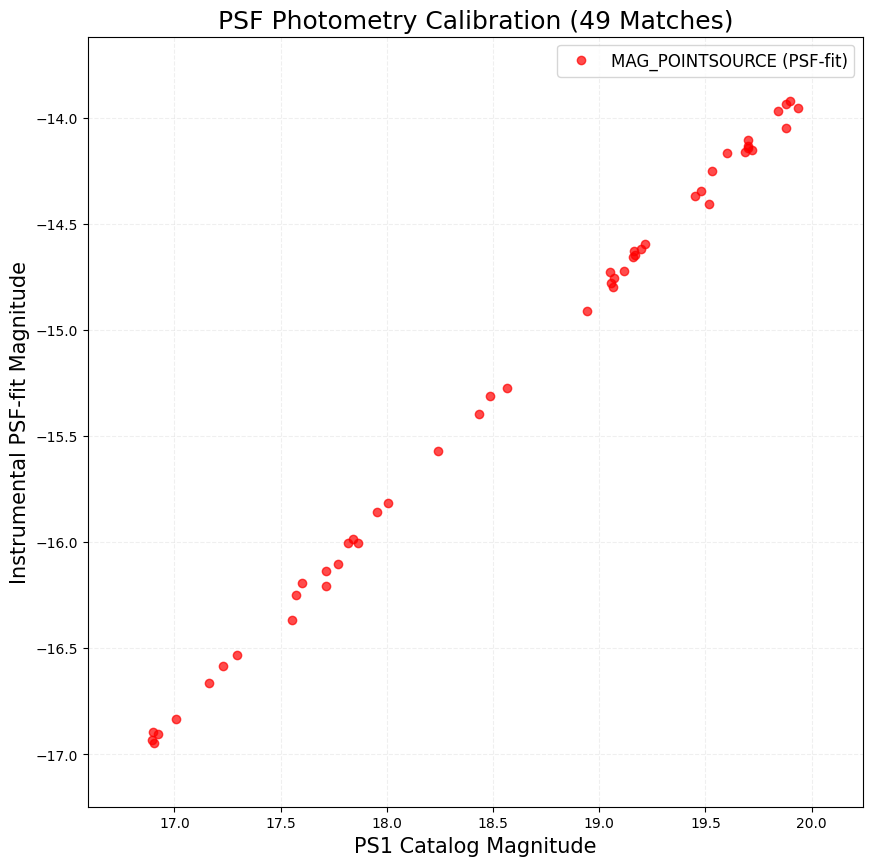

PSF Zero Point: 33.8258 +/- 0.0363


In [ ]:
plt.figure(figsize=(10, 10))

# 1. Plot the PSF-fit magnitudes
# X = Catalog G-mag (PS1)
# Y = Instrumental PSF magnitude (SExtractor Model)
plt.plot(
    good_cat_stars['rmag'][idx_psfps1], 
    cleanPSFSources['MAG_POINTSOURCE'][idx_psfimage], 
    'r.', 
    markersize=12, 
    label='MAG_POINTSOURCE (PSF-fit)',
    alpha=0.7
)

# 2. AUTO-SCALING (Best for seeing the full line)
plt.autoscale(enable=True, axis='both', tight=False)
plt.margins(0.1) # 10% safety buffer

plt.xlabel('PS1 Catalog Magnitude', fontsize=15)
plt.ylabel('Instrumental PSF-fit Magnitude', fontsize=15)
plt.title(f'PSF Photometry Calibration ({len(idx_psfimage)} Matches)', fontsize=18)
plt.legend(fontsize=12)
plt.grid(alpha=0.2, linestyle='--')
plt.show()

# 3. STATS: How much better is the PSF fit?
psf_offsets = good_cat_stars['rmag'][idx_psfps1] - cleanPSFSources['MAG_POINTSOURCE'][idx_psfimage]
psf_mean, psf_med, psf_std = sigma_clipped_stats(psf_offsets)
print(f"PSF Zero Point: {psf_med:.4f} +/- {psf_std:.4f}")


### Zero-point derivation

Note how the PSF-fit magnitudes deviate from a straight line at the bright end -- this is because the PSF starts becoming saturated on top of very bright stars, leading to poor PSF fits. These will be automatically clipped when we do the 3 sigma clipping for deriving the zero-point. As in the case of aperture photometry, compute a PSF photometry zero-point by sigma-clipping on the offsets between the PSF-fit and PS1 magnitudes. Print the results.

In [ ]:
import numpy.ma as ma
from astropy.stats import sigma_clipped_stats

# 1. Array of differences between the catalog and PSF-convolved instrumental magnitudes
psfoffsets = ma.array(good_cat_stars['rmag'][idx_psfps1] - cleanPSFSources['MAG_POINTSOURCE'][idx_psfimage])

# 2. Compute sigma clipped statistics (using maxiters=10 to avoid the TypeError)
# This will automatically ignore any bad matches or noisy outliers
zero_psfmean, zero_psfmed, zero_psfstd = sigma_clipped_stats(psfoffsets, sigma=3.0, maxiters=10)

# 3. Clean Print
print(f"--- PSF ZERO POINT CALIBRATED ---")
print(f"PSF Mean ZP:   {zero_psfmean:.4f}")
print(f"PSF Median ZP: {zero_psfmed:.4f}")
print(f"PSF STD Dev:    {zero_psfstd:.4f}") # This should ideally be < 0.05


--- PSF ZERO POINT CALIBRATED ---
PSF Mean ZP:   33.8330
PSF Median ZP: 33.8258
PSF STD Dev:    0.0363


In order to obtain a PSF-fit magnitude for our favorite source, we can directly read off the SExtractor PSF-fit photometry table for the coordinates of our source by cross-matching the table coordinates to the coordinates of our source.

Now obtain the PSF-fit magnitude of the source from SExtractor catalog and print the result.

In [ ]:
import os
import astropy.units as u
from astropy.coordinates import SkyCoord

# 1. Load the PSF Catalog (Ensure we point to the correct file in Photometry)
# Your imageName should be 'coadded_astrometrically_corrected_rband_r70.fits'
psfCatalogPath = os.path.join(workDir, imageName + '.psf.cat')
psfsourceTable = get_table_from_ldac(psfCatalogPath)

# 2. Target Coordinates (Your rounded values)
ra_target, dec_target = 64.4, 7.93
target_coord = SkyCoord(ra=ra_target, dec=dec_target, frame='icrs', unit='degree')

# 3. Create Searchable Catalog Coordinates
# Using WIN_J2000 for the highest astrometric precision
catalog_coords = SkyCoord(
    ra=psfsourceTable['ALPHAWIN_J2000'], 
    dec=psfsourceTable['DELTAWIN_J2000'], 
    unit=u.deg
)

# 4. Find the SINGLE CLOSEST source (Match to catalog)
idx, d2d, _ = target_coord.match_to_catalog_sky(catalog_coords)

# 5. Extract and Calibrate the Magnitude
mag_psf_instr = psfsourceTable[idx]['MAG_POINTSOURCE']
mag_psf_err = psfsourceTable[idx]['MAGERR_POINTSOURCE']

# Apply your zero point (using the median ZP we just calculated)
final_mag = mag_psf_instr + zero_psfmed
# Combine instrumental error and calibration uncertainty
final_err = np.sqrt(mag_psf_err**2 + zero_psfstd**2)

print(f"--- TARGET CALIBRATION RESULTS ---")
print(f"Source found at distance: {d2d.arcsec[0]:.3f} arcsec")
print(f"Instrumental PSF Mag:    {mag_psf_instr:.3f}")
print(f"PSF Zero Point:           {zero_psfmed:.3f}")
print(f"\nFINAL CALIBRATED MAGNITUDE: {final_mag:.3f} +/- {final_err:.3f}")


--- TARGET CALIBRATION RESULTS ---
Source found at distance: 2.887 arcsec
Instrumental PSF Mag:    -10.260
PSF Zero Point:           33.826

FINAL CALIBRATED MAGNITUDE: 23.566 +/- 0.039


The aperture-corrected magnitudes and PSF-fit magnitudes should be consistent with each other.

Getting corrected magnitudes for one arc min around target

In [ ]:
# 1. Load updated PSF Catalog
psfCatalogPath = os.path.join(workDir, imageName + '.psf.cat')
psfsourceTable = get_table_from_ldac(psfCatalogPath)

# 2. Target Region (0.5-arcminute radius = 1 arcminute total width)
target_center = SkyCoord('04h17m35.9058s', '+07d55m51.9812s', frame='icrs')
catalog_coords = SkyCoord(ra=psfsourceTable['ALPHAWIN_J2000'], dec=psfsourceTable['DELTAWIN_J2000'], unit=u.deg)

# Calculate separation (Filtering for the 1' x 1' box)
separations = target_center.separation(catalog_coords)
in_region = separations < (0.5 * u.arcmin) # 0.5 arcmin radius

# 3. Apply SNR > 5 Cutoff and Region Filter
region_sources = psfsourceTable[in_region & (psfsourceTable['SNR_WIN'] > 10)]

# 4. Calibrate and Store Results
calibrated_data = []

for src in region_sources:
    # Instrumental Magnitude
    mag_instr = src['MAG_POINTSOURCE']
    mag_err_instr = src['MAGERR_POINTSOURCE']
    
    # Apply Zero Point Correction (using our zero_psfmed)
    mag_calib = mag_instr + zero_psfmed
    mag_err_calib = np.sqrt(mag_err_instr**2 + zero_psfstd**2)
    
    calibrated_data.append({
        'RA': src['ALPHAWIN_J2000'], 'Dec': src['DELTAWIN_J2000'],
        'X_IMAGE': src['XMODEL_IMAGE'], 'Y_IMAGE': src['YMODEL_IMAGE'],
        'MAG_CALIB': round(mag_calib, 3), 'MAGERR_CALIB': round(mag_err_calib, 3),
        'SNR': round(src['SNR_WIN'], 2), 'ELLIPTICITY': round(src['ELONGATION'] - 1.0, 3),
        'FLUX_RADIUS': round(src['FLUX_RADIUS'], 2),
        'AWIN': src['AWIN_IMAGE'], 'BWIN': src['BWIN_IMAGE'], 'THETAWIN': src['THETAWIN_IMAGE'],
        'FLAGS': src['FLAGS']
    })

# 5. Export to CSV
df = pd.DataFrame(calibrated_data)
output_csv = os.path.join(workDir, 'target_region_photometry.csv')
df.to_csv(output_csv, index=False)

print(f"--- Extraction Complete ---")
print(f"Found {len(df)} sources with SNR > 5 in the 1x1 arcminute region.")


--- Extraction Complete ---
Found 12 sources with SNR > 5 in the 1x1 arcminute region.


In [ ]:
import os
import sys
from pathlib import Path
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
from matplotlib.patches import Circle
import astropy.units as u
from astropy.coordinates import SkyCoord

if "cal" not in globals():
    _cwd = Path.cwd().resolve()
    if (_cwd / "calibrate_photometry.py").is_file():
        _cp = _cwd / "calibrate_photometry.py"
        _spec = importlib.util.spec_from_file_location("calibrate_photometry", _cp)
        cal = importlib.util.module_from_spec(_spec)
        _spec.loader.exec_module(cal)
    else:
        for _r in [_cwd, *_cwd.parents]:
            _cp = _r / "tools" / "Photometry" / "calibrate_photometry.py"
            if _cp.is_file():
                _spec = importlib.util.spec_from_file_location("calibrate_photometry", _cp)
                cal = importlib.util.module_from_spec(_spec)
                _spec.loader.exec_module(cal)
                break
        else:
            raise ImportError("Could not find calibrate_photometry.py")
workDir = cal.resolve_photometry_workdir()
if workDir not in sys.path:
    sys.path.insert(0, workDir)
from r70_cutout_for_plot import resolve_r70_plot_image

# 0. Calibration CSV is produced by the standalone script (not by this notebook). From
# ``tools/Photometry`` run:  python calibrate_photometry.py
# That writes ``r70_target_comparison_photometry.csv`` (WSL: source-extractor, psfex; network for PS1/LS).

# 1. Target Center (The anchor)
target_center = SkyCoord('04h17m35.9058s', '+07d55m51.9812s', frame='icrs')
c_ra, c_dec = target_center.ra.deg, target_center.dec.deg

# CALCULATE THE 5 SYMMETRIC POINTS (Ticks every 15 arcseconds)
# Dec axis: Center, ±15", ±30"
dec_ticks = [c_dec - 30/3600, c_dec - 15/3600, c_dec, c_dec + 15/3600, c_dec + 30/3600]

# RA axis: Calculated to match 15" on-sky distance exactly at this Dec
cos_dec = np.cos(np.deg2rad(c_dec))
ra_step_deg = (15/3600) / cos_dec
ra_ticks = [c_ra - 2*ra_step_deg, c_ra - ra_step_deg, c_ra, c_ra + ra_step_deg, c_ra + 2*ra_step_deg]

# 2. Load image: prefer *_cutout.fits if WCS says ~1'; else extract 1' from full coadd (see r70_cutout_for_plot.py)
cutoutPath, _cutout_log = resolve_r70_plot_image(workDir, target_center)
print(_cutout_log)

hdu = fits.open(cutoutPath)[0]
data = hdu.data
wcs = WCS(hdu.header)

csvPath = os.path.join(workDir, 'r70_target_comparison_photometry.csv')
df = pd.read_csv(csvPath)

# 2b. AstroPath posteriors (r70): match by sky position to sources with PATH output
_base = os.path.dirname(workDir)
_post_candidates = [
    os.path.join(_base, 'AstroPath', 'results', 'r70_posterior.csv'),
    os.path.join(_base, 'tools', 'AstroPath', 'results', 'r70_posterior.csv'),
]
post_csv = next((p for p in _post_candidates if os.path.isfile(p)), _post_candidates[0])
posterior_per_row = np.full(len(df), np.nan)
if os.path.isfile(post_csv):
    post_df = pd.read_csv(post_csv)
    c_df = SkyCoord(ra=df['RA'].values * u.deg, dec=df['Dec'].values * u.deg)
    c_post = SkyCoord(ra=post_df['ra'].values * u.deg, dec=post_df['dec'].values * u.deg)
    match_idx, sep2d, _ = c_df.match_to_catalog_sky(c_post)
    ok = sep2d < 0.5 * u.arcsec
    for i in range(len(df)):
        if ok[i]:
            posterior_per_row[i] = float(post_df['posterior_O'].iloc[match_idx[i]])

# 3. Setup Plot
plt.figure(figsize=(15, 15))
ax = plt.subplot(projection=wcs)
ax.set_aspect('equal', adjustable='box') 

# Force tight edges (Exactly 1 arcminute width/height)
ax.set_xlim(-0.5, data.shape[1] - 0.5)
ax.set_ylim(-0.5, data.shape[0] - 0.5)

# 4. COORDINATE FORMATTING (5-Point Alignment)
ax.coords[0].set_major_formatter('hh:mm:ss.sss')
ax.coords[1].set_major_formatter('dd:mm:ss.ss')

# Apply the 5-point calibration to the ticks
ax.coords[0].set_ticks(values=ra_ticks * u.deg)
ax.coords[1].set_ticks(values=dec_ticks * u.deg)

# Display Image (ZScale)
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data)
plt.imshow(data, vmin=vmin, vmax=vmax, origin='lower', cmap='gray')

# 5. Mark sources (comparison table has FLUX_RADIUS, not SExtractor window ellipses)
scaling = 1
for row_i, (_, row) in enumerate(df.iterrows()):
    pix_coord = wcs.all_world2pix([[row['RA'], row['Dec']]], 0)
    x, y = pix_coord[0]
    
    r_pix = float(row['FLUX_RADIUS'])
    r_draw = max(2.0, r_pix) * scaling
    circ = Circle(
        xy=(x, y), radius=r_draw, edgecolor='red', facecolor='none',
        linewidth=1.5, alpha=0.6,
    )
    ax.add_patch(circ)
    
    mag = float(row['MAG_CALIB_APER_40PX'])
    if not np.isfinite(mag):
        continue
    p = posterior_per_row[row_i]
    if np.isfinite(p):
        label = f"{mag:.2f}\nP={p:.3f}"
    else:
        label = f"{mag:.2f}"
    plt.text(x, y - (r_draw * 2.5), label,
             color='cyan', fontsize=10, fontweight='bold', ha='center',
             bbox=dict(facecolor='black', alpha=0.5, pad=0.5, edgecolor='none'))

# 6. GREEN TARGET MARKER (1" RADIUS)
target_pix = wcs.all_world2pix([[c_ra, c_dec]], 0)
target_marker = Circle(
    (target_pix[0][0], target_pix[0][1]), radius=(1.0/3600.0), 
    transform=ax.get_transform('icrs'), edgecolor='lime', facecolor='none', linewidth=2.5
)
ax.add_patch(target_marker)

plt.title("r70 Astropath", fontsize=22, pad=20)
plt.grid(alpha=0.4, linestyle=':', color='white')
out_fig = os.path.join(workDir, 'r70_astropath_overlay.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()



NameError: name 'workDir' is not defined